<a href="https://colab.research.google.com/github/ishaandindwar/my-projects/blob/main/Art_Extract_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python

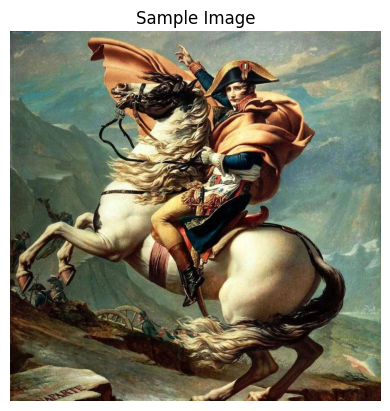

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg')

if img is None:
    print("Error: Could not load image. Please check if 'image.jpg' exists and the path is correct.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Sample Image")
    plt.axis('off')
    plt.show()

In [5]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# Load pretrained model
model = models.resnet18(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [7]:
def extract_features(image_path):
    img = Image.open(image_path).convert('RGB')
    img = transform(img).unsqueeze(0)

    with torch.no_grad():
        features = model(img)

    return features.squeeze().numpy()

In [8]:
import numpy as np

def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (
        np.linalg.norm(vec1) * np.linalg.norm(vec2)
    )

In [9]:
img1 = extract_features('image.jpg')
img2 = extract_features('image2.jpg')

score = cosine_similarity(img1, img2)
print("Similarity:", score)

Similarity: 0.41631168


In [12]:
dataset = ['image.jpg', 'image2.jpg', 'image3.jpg']

features = {}

for img_path in dataset:
    features[img_path] = extract_features(img_path)

query = extract_features('query.jpg')

results = []

for img_path in dataset:
    sim = cosine_similarity(query, features[img_path])
    results.append((img_path, sim))

results.sort(key=lambda x: x[1], reverse=True)

print("Top similar images:")
for r in results[:3]:
    print(r)

Top similar images:
('image.jpg', np.float32(0.58180916))
('image2.jpg', np.float32(0.49064296))
('image3.jpg', np.float32(0.32274878))
